In [3]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
import pandas as pd
import matplotlib.ticker as ticker

In [4]:
workspace_base_path = lambda item: os.path.join('/checkpoint/maui/zhaobc/scientist/workspace', 'nanogpt_speedrun', item)

In [5]:
ori_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/nanogpt_speedrun/record_*_20250404_*',
        '/checkpoint/maui/zhaobc/scientist/workspace/nanogpt_speedrun/record_*_20250405_*'
    ]
)

Found 187 directories


In [17]:
folder_info = ori_results

r1_bon_dummy_no_knowledge_l0 = []
r1_bon_dummy_no_knowledge_l1 = []
o3_bon_dummy_no_knowledge_l0 = []
o3_bon_dummy_no_knowledge_l1 = []
r1_aide_dummy_no_knowledge_l0 = []
r1_aide_dummy_no_knowledge_l1 = []
r1_aide_base_knowledge_l1 = []

for folder_name, info in folder_info.items():
    if info['model'] == 'deepseek-r1':
        if info['runner'] == 'bon':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 0:
                    print(f"{folder_name}: r1, bon, dummy, coder nok")
                    r1_bon_dummy_no_knowledge_l0.append(folder_name)
                elif info['levels'][0] == 1:
                    print(f"{folder_name}: r1, bon, dummy, coder nok")
                    r1_bon_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
# print o3, bon, dummy ideator, coder no knowledge
for folder_name, info in folder_info.items():
    if info['model'] == 'o3-mini':
        if info['runner'] == 'bon':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 0:
                    print(f"{folder_name}: o3, bon, dummy, coder nok")
                    o3_bon_dummy_no_knowledge_l0.append(folder_name)
                elif info['levels'][0] == 1:
                    print(f"{folder_name}: o3, bon, dummy, coder nok")
                    o3_bon_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
# print r1, aide, dummy ideator, coder no knowledge
for folder_name, info in folder_info.items():
    if info['model'] == 'deepseek-r1':
        if info['runner'] == 'aide':
            if info['ideator'] == 'dummy':
                if info['levels'][0] == 0:
                    print(f"{folder_name}: r1, aide, dummy, coder nok")
                    r1_aide_dummy_no_knowledge_l0.append(folder_name)
                elif info['levels'][0] == 1:
                    print(f"{folder_name}: r1, aide, dummy, coder nok")
                    r1_aide_dummy_no_knowledge_l1.append(folder_name)

print("--" * 10)
# print r1, aide, base ideator, coder knowledge
for folder_name, info in folder_info.items():
    if info['model'] == 'deepseek-r1':
        if info['runner'] == 'aide':
            if info['ideator'] == 'base':
                if info['knowledge_coder']:
                    if info['levels'][0] == 1:
                        print(f"{folder_name}: r1, aide, base, coder k")
                        r1_aide_base_knowledge_l1.append(folder_name)

record_3_20250404_163427_044305: r1, bon, dummy, coder nok
record_11_20250404_172438_121239: r1, bon, dummy, coder nok
record_1_20250404_163433_747335: r1, bon, dummy, coder nok
record_9_20250404_163427_210339: r1, bon, dummy, coder nok
record_5_20250404_163427_174154: r1, bon, dummy, coder nok
record_10_20250404_163426_762312: r1, bon, dummy, coder nok
record_2_20250404_163420_681183: r1, bon, dummy, coder nok
record_8_20250404_163416_353958: r1, bon, dummy, coder nok
record_8_20250404_163431_459644: r1, bon, dummy, coder nok
record_3_20250404_163416_194331: r1, bon, dummy, coder nok
record_11_20250404_170532_676386: r1, bon, dummy, coder nok
record_5_20250404_163415_733295: r1, bon, dummy, coder nok
record_7_20250404_163426_865626: r1, bon, dummy, coder nok
record_2_20250404_163431_310326: r1, bon, dummy, coder nok
record_6_20250404_163432_020508: r1, bon, dummy, coder nok
record_7_20250404_163416_354160: r1, bon, dummy, coder nok
record_10_20250404_163419_330926: r1, bon, dummy, cod

In [6]:
print(f"len(r1_bon_dummy_no_knowledge_l0): {len(r1_bon_dummy_no_knowledge_l0)}")
print(f"len(r1_bon_dummy_no_knowledge_l1): {len(r1_bon_dummy_no_knowledge_l1)}")
print(f"len(o3_bon_dummy_no_knowledge_l0): {len(o3_bon_dummy_no_knowledge_l0)}")
print(f"len(o3_bon_dummy_no_knowledge_l1): {len(o3_bon_dummy_no_knowledge_l1)}")
print(f"len(r1_aide_dummy_no_knowledge_l0): {len(r1_aide_dummy_no_knowledge_l0)}")
print(f"len(r1_aide_dummy_no_knowledge_l1): {len(r1_aide_dummy_no_knowledge_l1)}")
print(f"len(r1_aide_base_knowledge_l1): {len(r1_aide_base_knowledge_l1)}")


len(r1_bon_dummy_no_knowledge_l0): 11
len(r1_bon_dummy_no_knowledge_l1): 11
len(o3_bon_dummy_no_knowledge_l0): 11
len(o3_bon_dummy_no_knowledge_l1): 11
len(r1_aide_dummy_no_knowledge_l0): 12
len(r1_aide_dummy_no_knowledge_l1): 11
len(r1_aide_base_knowledge_l1): 4


In [25]:
r1_bon_dummy_no_knowledge_l0 = {k: folder_info[k] for k in r1_bon_dummy_no_knowledge_l0}
r1_bon_dummy_no_knowledge_l1 = {k: folder_info[k] for k in r1_bon_dummy_no_knowledge_l1}
o3_bon_dummy_no_knowledge_l0 = {k: folder_info[k] for k in o3_bon_dummy_no_knowledge_l0}
o3_bon_dummy_no_knowledge_l1 = {k: folder_info[k] for k in o3_bon_dummy_no_knowledge_l1}
r1_aide_dummy_no_knowledge_l0 = {k: folder_info[k] for k in r1_aide_dummy_no_knowledge_l0}
r1_aide_dummy_no_knowledge_l1 = {k: folder_info[k] for k in r1_aide_dummy_no_knowledge_l1}
r1_aide_base_knowledge_l1 = {k: folder_info[k] for k in r1_aide_base_knowledge_l1}

In [31]:
r1_bon_dummy_no_knowledge_l1['record_9_20250404_163419_329785']

{'record': 9,
 'levels': [1],
 'ideator': 'dummy',
 'knowledge_coder': False,
 'runner': 'bon',
 'model': 'deepseek-r1',
 'metrics':    step  val_loss  train_time
 0     0    3.2785    505531.0
 1     1    3.2757    490921.0
 2     2       NaN         NaN
 3     3       NaN         NaN
 4     4       NaN         NaN}

In [32]:
o3_bon_dummy_no_knowledge_l1['record_9_20250404_163507_962599']

{'record': 9,
 'levels': [1],
 'ideator': 'dummy',
 'knowledge_coder': False,
 'runner': 'bon',
 'model': 'o3-mini',
 'metrics':    step  val_loss  train_time
 0     0    3.2785    505531.0
 1     1    3.2877    473544.0
 2     2       NaN         NaN
 3     3       NaN         NaN}

In [43]:
o3_bon_dummy_no_knowledge_l1['record_9_20250404_163507_962599']['metrics']

,step,val_loss,train_time
0,0,3.2785,505531.0
1,1,3.2877,473544.0
2,2,NaN,NaN
3,3,NaN,NaN


In [33]:
r1_aide_dummy_no_knowledge_l1['record_9_20250404_163327_136577']

{'record': 9,
 'levels': [1],
 'ideator': 'dummy',
 'knowledge_coder': False,
 'runner': 'aide',
 'model': 'deepseek-r1',
 'metrics':     step  val_loss  train_time
 0      0    3.2785      505531
 1      1    3.2767      499559
 2      2    3.2792      486178
 3      3    3.2742      483892
 4      4    3.2787      495007
 5      5    3.2793      491262
 6      6    3.2788      486228
 7      7    3.2781      485864
 8      8    3.2759      490455
 9      9    3.2800      488231
 10    10    3.2755      495164
 11    11    4.4400      524465
 12    12    3.9415      523458
 13    13    3.3742      500455
 14    14    3.9437      523594
 15    15    3.6193      516226
 16    16    3.5009      520753
 17    17    3.4427      512007
 18    18    3.3973      518219
 19    19    3.4037      491410
 20    20    3.4268      493677
 21    21    3.4334      499763
 22    22    3.4555      488835
 23    23    3.4539      498135
 24    24    3.4458      492133
 25    25    3.4511      492909
 26

In [34]:
def track_data(record, level, new_results_dict):
    # Initialize lists to store the cumulative min train time and the corresponding val loss
    cum_min_train_time = []
    corresponding_val_loss = []
    
    # Initialize the current min train time and the corresponding val loss
    current_min_train_time = float('inf')
    current_corresponding_val_loss = None
    
    # Iterate over the rows in the dataframe
    for index, row in new_results_dict[f'record_{record}_{level}'][1]['metrics'].iterrows():
        # If the current train time is smaller than the current min train time, update the current min train time and the corresponding val loss
        if row['train_time'] < current_min_train_time:
            current_min_train_time = row['train_time']
            current_corresponding_val_loss = row['val_loss']
    
        if np.isnan(row['train_time']) and np.isnan(row['val_loss']):
            continue
        if row['val_loss'] > 5:
            continue
        # Append the current min train time and the corresponding val loss to the lists
        cum_min_train_time.append(current_min_train_time)
        corresponding_val_loss.append(current_corresponding_val_loss)
    
    # Convert the lists to pandas Series
    best_train_time_searched = pd.Series(cum_min_train_time)
    best_val_loss_at_min_train_time = pd.Series(corresponding_val_loss)
    return best_train_time_searched, best_val_loss_at_min_train_time

In [35]:
def gather_data_from_results(results, range_list=[1,2,3,4,5,6,7,8,9,10,11]):
    for key, value in results.items():
        metrics = gather_metrics(
            workspace_path=workspace_base_path(key),
            metrics=['val_loss', 'train_time'],
            workspace_template_path=os.path.join(
                'workspace_templates', 
                'nanogpt_speedrun', 
                f"record_{value['record']}"
            )
        )
        results[key]['metrics'] = metrics
    # get uniq record and levels
    uniq_records = list(set([item['record'] for item in results.values()]))
    uniq_levels = list(set([item['levels'][0] for item in results.values()]))
    # get the dict with record and level as key
    # {record}_{level} : {metrics}
    
    new_results_keys = [
        f'record_{record}_{level}' 
        for record in range_list
            for level in uniq_levels
    ]
    # only get the first one from all results
    new_results_dict = {}
    for record in range_list:
        for level in uniq_levels:
            for item in results.items():
                if item[1]['record'] == record and item[1]['levels'][0] == level:
                    if f'record_{record}_{level}' not in new_results_dict \
                    or len(item[1]['metrics']['val_loss']) > \
                    len(new_results_dict[f'record_{record}_{level}'][1]['metrics']['val_loss']):
                        new_results_dict[f'record_{record}_{level}'] = item

    agent_record = {}

    assert len(uniq_levels) == 1
    for record in range_list:
        train_time, val_loss = track_data(record, uniq_levels[0], new_results_dict)
        train_time = train_time[val_loss < 3.32]
        agent_record[record+1] = train_time.min()
    return agent_record, uniq_levels

In [10]:
human_train_time_dict = {
    1: 2936369,
    2: 2304681,
    3: 1282839,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839
}
#     1	2936369
# 2	2304681
# 3	1282839
    # 4	3.2772	1301740
    # 5	3.2751	949528
    # 6	3.276	766259
    # 7	3.275	773072
    # 8	3.2789	662205
    # 9	3.2785	505531
    # 10	3.2782	477150
    # 11	3.2742	442985

In [36]:
r1_bon_dummy_no_knowledge_l0_record, uniq_levels = gather_data_from_results(r1_bon_dummy_no_knowledge_l0)
r1_bon_dummy_no_knowledge_l1_record, uniq_levels = gather_data_from_results(r1_bon_dummy_no_knowledge_l1)
o3_bon_dummy_no_knowledge_l0_record, uniq_levels = gather_data_from_results(o3_bon_dummy_no_knowledge_l0)
o3_bon_dummy_no_knowledge_l1_record, uniq_levels = gather_data_from_results(o3_bon_dummy_no_knowledge_l1)
r1_aide_dummy_no_knowledge_l0_record, uniq_levels = gather_data_from_results(r1_aide_dummy_no_knowledge_l0)
r1_aide_dummy_no_knowledge_l1_record, uniq_levels = gather_data_from_results(r1_aide_dummy_no_knowledge_l1)

In [37]:
r1_bon_dummy_no_knowledge_l1_record

{2: 2936369.0,
 3: 2304681.0,
 4: 1282839.0,
 5: 1301740.0,
 6: 949528.0,
 7: 766259.0,
 8: 773072.0,
 9: 662205.0,
 10: 490921.0,
 11: 477150.0,
 12: 442985.0}

In [39]:
o3_bon_dummy_no_knowledge_l1_record

{2: 2228366.0,
 3: 2304681.0,
 4: 1282839.0,
 5: 1086999.0,
 6: 949528.0,
 7: 766259.0,
 8: 700894.0,
 9: 662205.0,
 10: 473544.0,
 11: 477150.0,
 12: 442985.0}

In [40]:
r1_aide_dummy_no_knowledge_l1_record

{2: 2936369.0,
 3: 2304681.0,
 4: 1282839.0,
 5: 1030392.0,
 6: 949528.0,
 7: 766259.0,
 8: 773072.0,
 9: 662205.0,
 10: 483892.0,
 11: 477150.0,
 12: 442985.0}

In [12]:
def get_dict_for_ploting(kv_dict, range_list=[1,2,3,4,5,6,7,8,9,10,11]):
    return {k: v for k, v in kv_dict.items() if k in range_list}

In [13]:
# shift human record train time to the right by one
shifted_human_train_time_dict = {k+1: v for k, v in human_train_time_dict.items() if k < 11}

In [14]:
def create_comparison_plot(dict1, dict2, dict1_name, dict2_name, human_dict=None, 
                           shifted_human_dict=None, title=None, output_path=None):
    """
    Creates a comparison plot between two datasets, highlighting their differences.
    
    Parameters:
    -----------
    dict1, dict2 : dict
        Dictionaries with record numbers as keys and train times as values.
    dict1_name, dict2_name : str
        Names for the legend entries for dict1 and dict2.
    human_dict : dict, optional
        Dictionary with human baseline data.
    shifted_human_dict : dict, optional
        Dictionary with shifted human baseline data (upper bound).
    title : str, optional
        Custom title for the plot. If None, a default title is used.
    output_path : str, optional
        If provided, saves the plot to this path instead of displaying it.
        
    Returns:
    --------
    fig, ax : tuple
        The matplotlib figure and axis objects
    """
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot the main comparison lines
    plt.plot(
        dict1.keys(), 
        dict1.values(), 
        'b-o', markersize=5, linewidth=2, label=dict1_name
    )

    plt.plot(
        dict2.keys(), 
        dict2.values(), 
        'r-s', markersize=5, linewidth=2, label=dict2_name
    )
    
    # Add human baseline if provided
    if human_dict:
        plt.plot(
            human_dict.keys(), 
            human_dict.values(), 
            'k--o', linewidth=1.5, markersize=4, alpha=0.7, label='human_record_train_time'
        )
    
    # Add shifted human upper bound if provided
    if shifted_human_dict:
        plt.plot(
            shifted_human_dict.keys(), 
            shifted_human_dict.values(), 
            'm-.^', linewidth=2, markersize=5, label='shifted_human_train_time (upper bound)'
        )
    
    # Find common record numbers to highlight differences
    common_keys = sorted(set(dict1.keys()) & set(dict2.keys()))
    dict1_values = [dict1[k] for k in common_keys]
    dict2_values = [dict2[k] for k in common_keys]
    
    # Fill the area between the two lines to highlight the difference
    plt.fill_between(
        common_keys, 
        dict1_values, 
        dict2_values, 
        color='lightgreen', 
        alpha=0.5, 
        label='Difference'
    )
    
    # Add arrows and annotations for significant differences
    max_value = max(max(dict1_values), max(dict2_values))
    for i, k in enumerate(common_keys):
        if abs(dict1[k] - dict2[k]) > max_value * 0.1:  # Only annotate significant differences
            mid_point = (dict1[k] + dict2[k]) / 2
            plt.annotate(
                f"{abs(dict1[k] - dict2[k]):.0f} ms",
                xy=(k, mid_point),
                xytext=(k + 0.5, mid_point),
                fontsize=8,
                arrowprops=dict(arrowstyle='->', color='green', lw=1)
            )
    
    # Add labels and grid
    plt.xlabel('Record number', fontsize=12)
    plt.ylabel('Train Time in ms', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add a title
    if title:
        plt.title(title, fontsize=14)
    else:
        plt.title(f'Comparison: {dict1_name} vs {dict2_name}', fontsize=14)
    
    # Format the axis labels to show whole numbers
    def plain_formatter(x, pos):
        return f"{x:.0f}"
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
    plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(plain_formatter))
    
    # Add legend with a good position
    plt.legend(loc='best', fontsize=10)
    
    # Add a text box explaining the visualization
    explanation_lines = [
        'Difference Highlights:',
        '- Green area shows magnitude of difference',
        '- Annotations show significant gaps in ms',
    ]
    
    if human_dict:
        explanation_lines.append('- Black dashed line shows human baseline')
    
    if shifted_human_dict:
        explanation_lines.append('- Magenta line shows shifted human time (upper bound)')
        
    textstr = '\n'.join(explanation_lines)
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=props)
    
    # Adjust layout to make sure everything fits
    plt.tight_layout()
    
    # Save or show the plot
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()
        
    return fig, ax

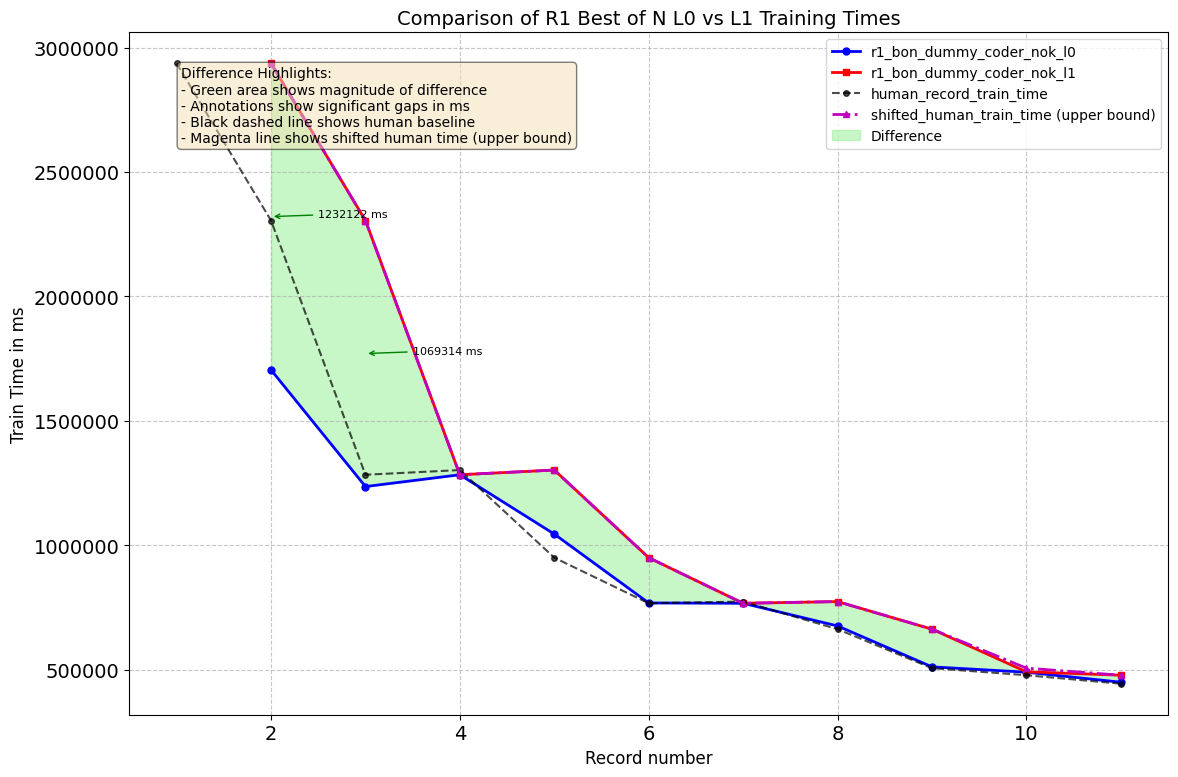

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Comparison of R1 Best of N L0 vs L1 Training Times'}, xlabel='Record number', ylabel='Train Time in ms'>)

In [15]:
create_comparison_plot(
    get_dict_for_ploting(r1_bon_dummy_no_knowledge_l0_record),
    get_dict_for_ploting(r1_bon_dummy_no_knowledge_l1_record),
    'r1_bon_dummy_coder_nok_l0',
    'r1_bon_dummy_coder_nok_l1',
    human_dict=get_dict_for_ploting(human_train_time_dict),
    shifted_human_dict=get_dict_for_ploting(shifted_human_train_time_dict),
    title='Comparison of R1 Best of N L0 vs L1 Training Times'
)

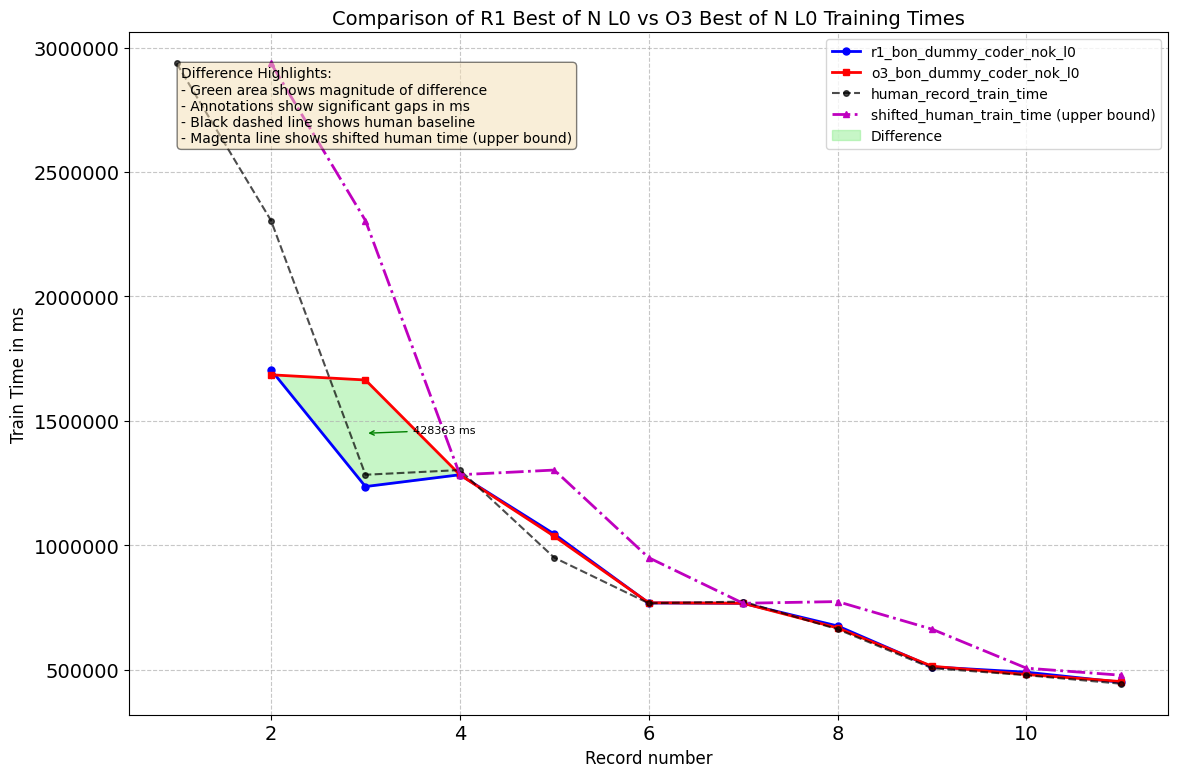

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Comparison of R1 Best of N L0 vs O3 Best of N L0 Training Times'}, xlabel='Record number', ylabel='Train Time in ms'>)

In [16]:
create_comparison_plot(
    get_dict_for_ploting(r1_bon_dummy_no_knowledge_l0_record),
    get_dict_for_ploting(o3_bon_dummy_no_knowledge_l0_record),
    'r1_bon_dummy_coder_nok_l0',
    'o3_bon_dummy_coder_nok_l0',
    human_dict=get_dict_for_ploting(human_train_time_dict),
    shifted_human_dict=get_dict_for_ploting(shifted_human_train_time_dict),
    title='Comparison of R1 Best of N L0 vs O3 Best of N L0 Training Times'
)

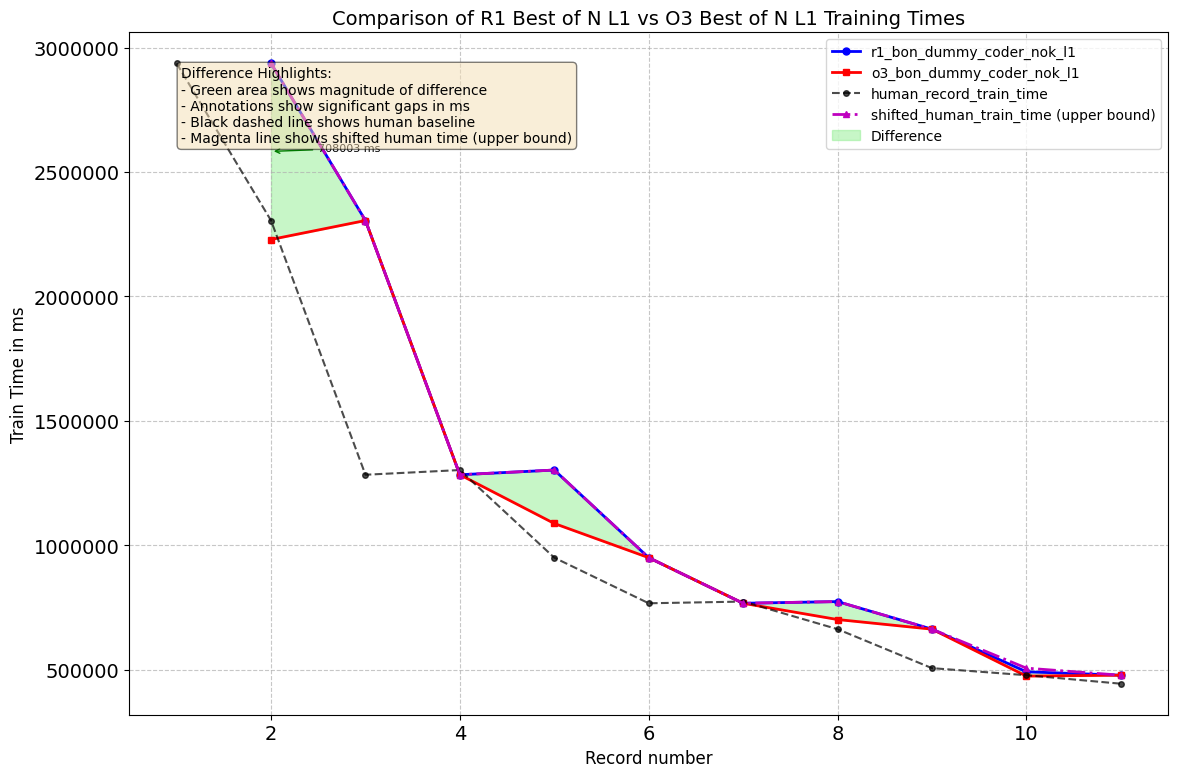

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Comparison of R1 Best of N L1 vs O3 Best of N L1 Training Times'}, xlabel='Record number', ylabel='Train Time in ms'>)

In [17]:
create_comparison_plot(
    get_dict_for_ploting(r1_bon_dummy_no_knowledge_l1_record),
    get_dict_for_ploting(o3_bon_dummy_no_knowledge_l1_record),
    'r1_bon_dummy_coder_nok_l1',
    'o3_bon_dummy_coder_nok_l1',
    human_dict=get_dict_for_ploting(human_train_time_dict),
    shifted_human_dict=get_dict_for_ploting(shifted_human_train_time_dict),
    title='Comparison of R1 Best of N L1 vs O3 Best of N L1 Training Times'
)

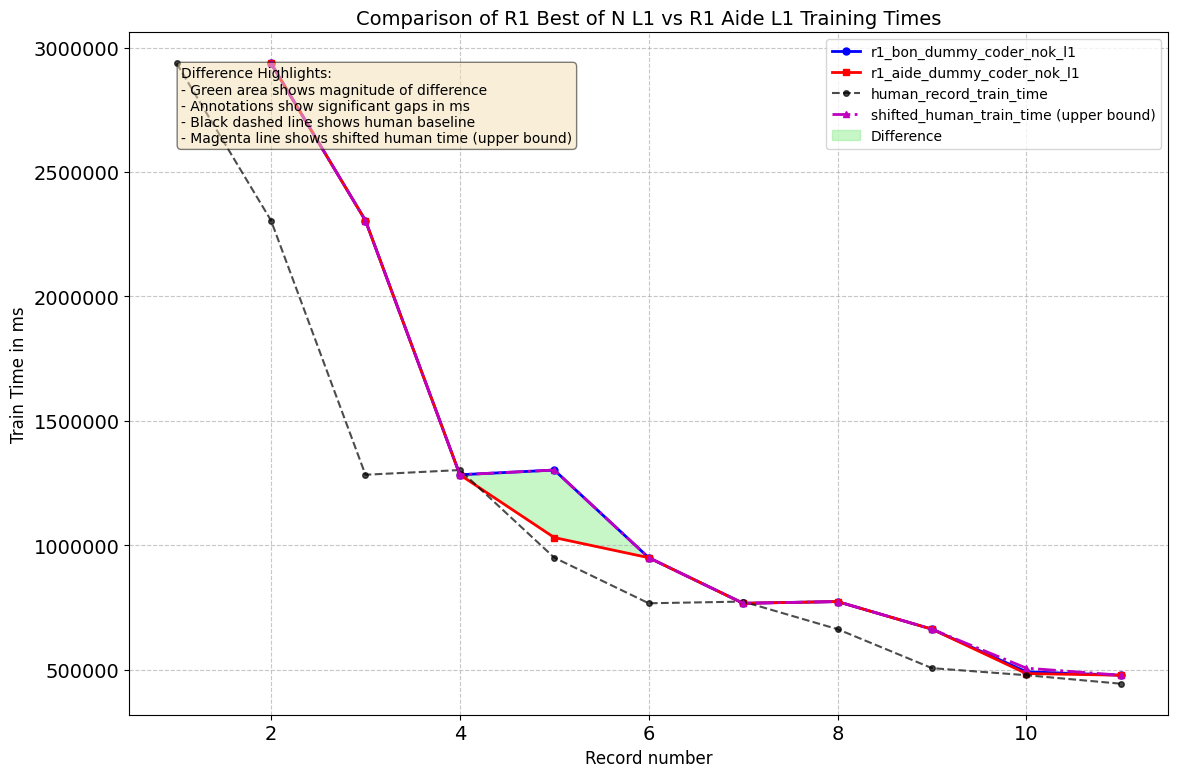

(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Comparison of R1 Best of N L1 vs R1 Aide L1 Training Times'}, xlabel='Record number', ylabel='Train Time in ms'>)

In [18]:
create_comparison_plot(
    get_dict_for_ploting(r1_bon_dummy_no_knowledge_l1_record),
    get_dict_for_ploting(r1_aide_dummy_no_knowledge_l1_record),
    'r1_bon_dummy_coder_nok_l1',
    'r1_aide_dummy_coder_nok_l1',
    human_dict=get_dict_for_ploting(human_train_time_dict),
    shifted_human_dict=get_dict_for_ploting(shifted_human_train_time_dict),
    title='Comparison of R1 Best of N L1 vs R1 Aide L1 Training Times'
)

In [ ]:
# r1_bon_dummy_no_knowledge_l0 = {k: folder_info[k] for k in r1_bon_dummy_no_knowledge_l0}
# r1_bon_dummy_no_knowledge_l1 = {k: folder_info[k] for k in r1_bon_dummy_no_knowledge_l1}
# o3_bon_dummy_no_knowledge_l0 = {k: folder_info[k] for k in o3_bon_dummy_no_knowledge_l0}
# o3_bon_dummy_no_knowledge_l1 = {k: folder_info[k] for k in o3_bon_dummy_no_knowledge_l1}
# r1_aide_dummy_no_knowledge_l0 = {k: folder_info[k] for k in r1_aide_dummy_no_knowledge_l0}
# r1_aide_dummy_no_knowledge_l1 = {k: folder_info[k] for k in r1_aide_dummy_no_knowledge_l1}